In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import normaltest, ttest_rel

In [32]:
sns.color_palette("Greens")

[(0.8828143021914648, 0.9546943483275664, 0.8621914648212226),
 (0.7371472510572856, 0.895517108804306, 0.7108342945021145),
 (0.5573241061130334, 0.8164244521337947, 0.546958861976163),
 (0.3388235294117647, 0.7117262591311034, 0.40584390618992694),
 (0.17139561707035755, 0.581514801999231, 0.2979008073817762),
 (0.017762399077277974, 0.44267589388696654, 0.18523644752018453)]

In [33]:
data_path = "../outputs/passives_document_uid.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]

In [34]:
uid_df[['factual', 'doc_name', 'pass_idx']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['pass_idx'] = uid_df['pass_idx'].astype(int)
passive_lookup = uid_df.groupby('doc_name').apply(lambda group: group['pass_idx'].unique()).to_dict()
uid_df['passive'] = uid_df.apply(lambda row: row['sent_idx'] in passive_lookup[row['doc_name']], axis=1)
uid_df['factual'] = ~((uid_df['factual'] == 'cf') 
                      & (uid_df['passive']))

In [35]:
uid_df.head()

,doc_id,sent_idx,context,sentence,uid_mean,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,doc_name,pass_idx,passive
0,f::GUM_academic_art::-1,0,sentence,Aesthetic Appreciation and Spanish Art:,8.942748,5.056778,4.469607,72.6147,15.7206,0.565461,-0.266276,8,True,GUM_academic_art,-1,False
1,f::GUM_academic_art::-1,0,prev1,Aesthetic Appreciation and Spanish Art:,8.942748,5.056778,4.469607,72.6147,15.7206,0.565461,-0.266276,8,True,GUM_academic_art,-1,False
2,f::GUM_academic_art::-1,0,prev3,Aesthetic Appreciation and Spanish Art:,8.942748,5.056778,4.469607,72.6147,15.7206,0.565461,-0.266276,8,True,GUM_academic_art,-1,False
3,f::GUM_academic_art::-1,0,document,Aesthetic Appreciation and Spanish Art:,8.942748,5.056778,4.469607,72.6147,15.7206,0.565461,-0.266276,8,True,GUM_academic_art,-1,False
4,f::GUM_academic_art::-1,0,"sent[-2,+0]",Aesthetic Appreciation and Spanish Art:,8.942748,5.056778,4.469607,72.6147,15.7206,0.565461,-0.266276,8,True,GUM_academic_art,-1,False


In [36]:
context_lvl = 'document'
passive_cf_comparison = uid_df[
       (uid_df['context'] == context_lvl)
       & (uid_df['passive'])
       ]
passive_cf_comparison['pass_cf'] = (passive_cf_comparison['passive'] & ~passive_cf_comparison['factual'])
passive_cf_comparison['sentence_label'] = passive_cf_comparison.apply(
       lambda row: "Counterfactual" if not row['factual'] else "Factual" if row['passive'] else "Unmanipulated", 
       axis=1)
passive_cf_comparison['doc_sent'] = passive_cf_comparison['doc_name'] + passive_cf_comparison['sent_idx'].astype(str)
passive_cf_comparison = passive_cf_comparison.groupby(['doc_name', 'sent_idx', 'factual']).first().reset_index()
passive_cf_comparison.head()

,doc_name,sent_idx,factual,doc_id,context,sentence,uid_mean,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,pass_idx,passive,pass_cf,sentence_label,doc_sent
0,GUM_academic_art,20,False,cf::GUM_academic_art::20,document,An interaction between the goals of the observ...,4.183554,4.337929,3.757265,39.046078,16.582534,1.036900,-0.090110,39,20,True,True,Counterfactual,GUM_academic_art20
1,GUM_academic_art,20,True,f::GUM_academic_art::-1,document,The direction of saccades is determined by an ...,3.951922,3.995256,3.475502,31.792666,14.887443,1.010965,-0.035070,40,-1,True,False,Factual,GUM_academic_art20
2,GUM_academic_census,22,False,cf::GUM_academic_census::22,document,"For example, averaging will wash differences i...",7.318855,5.619786,4.880660,58.579789,19.371397,0.767851,-0.220749,30,22,True,True,Counterfactual,GUM_academic_census22
3,GUM_academic_census,22,True,f::GUM_academic_census::-1,document,"For example, differences in recruitment and re...",6.407569,5.311130,4.524107,72.608536,18.221238,0.828884,-0.045842,32,-1,True,False,Factual,GUM_academic_census22


In [37]:
passive_cf_comparison['factual'].mean()

np.float64(0.5)

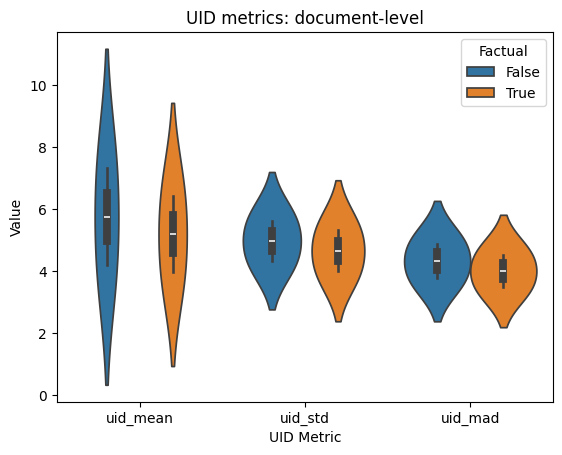

In [38]:
fig, ax = plt.subplots()
sns.violinplot(data=passive_cf_comparison.melt(
       id_vars=['factual'],
       value_vars=['uid_mean', 'uid_std', 'uid_mad'],
       var_name='UID Metric',
       value_name='Value'
       ), 
        hue='factual', y='Value', x='UID Metric', ax=ax)
plt.title(f"UID metrics: {context_lvl}-level")
handles, labels = ax.get_legend_handles_labels()
plt.legend(title="Factual")

In [39]:
np.diff(np.array([0, 3, 4, 8]))

array([3, 1, 4])

In [40]:
pw_diffs = (passive_cf_comparison
            .groupby(['doc_name','sent_idx'])
            [['uid_mean', 'uid_std', 'uid_mad']]
            .apply(
                lambda g: g.diff().iloc[1]
                )
            .reset_index())
pw_diffs

,doc_name,sent_idx,uid_mean,uid_std,uid_mad
0,GUM_academic_art,20,-0.231631,-0.342672,-0.281763
1,GUM_academic_census,22,-0.911285,-0.308657,-0.356553


Text(0.5, 0, '')

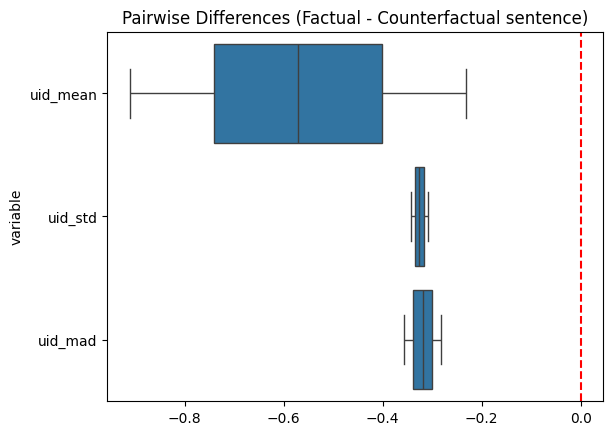

In [41]:
sns.boxplot(pw_diffs.melt(id_vars=['doc_name', 'sent_idx']), x='value', y='variable')
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Pairwise Differences (Factual - Counterfactual sentence)")
plt.xlabel('')

In [42]:
def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

In [43]:
results = []
metrics = ['uid_mean', 'uid_std', 'uid_mad']
for metric in metrics:
    obs, sim, p_val = perm_test(passive_cf_comparison, 'factual', metric, 10000,
                            test_stat=lambda a, b: a-b,
                            compare_fn=lambda sim, obs: sim >= obs)
    results.append({
        "metric": metric,
        "pval": p_val,
        "observed": obs,
        "simulated": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [44]:
print(results[['metric', 'observed', 'pval']].to_markdown())

|    | metric   |   observed |   pval |
|---:|:---------|-----------:|-------:|
|  0 | uid_mean |   0.571458 | 0.3331 |
|  1 | uid_std  |   0.325665 | 0.3296 |
|  2 | uid_mad  |   0.319158 | 0.3344 |


### Diff. in means test results
|    | metric   |   test statistic (CF - F) |   p-value |
|---:|:---------|-----------:|-------:|
|  0 | uid_mean |   0.489282 | 0.0002 |
|  1 | uid_std  |   0.344276 | 0.0001 |
|  2 | uid_mad  |   0.302887 | 0      |

In [45]:
results = []
for metric in ['uid_mean', 'uid_std', 'uid_mad']:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = passive_cf_comparison.loc[passive_cf_comparison['factual'], metric]
    cfactuals = passive_cf_comparison.loc[~passive_cf_comparison['factual'], metric]
    ttest_res = ttest_rel(factuals, cfactuals, alternative='less')
    results.append({
        'metric': metric,
        'normal_stat': normal_res.statistic,
        'normal_pval': normal_res.pvalue,
        'ttest_stat': ttest_res.statistic,
        'ttest_pval': ttest_res.pvalue
    })
results = pd.DataFrame(results)

/var/folders/sj/59v4c3dd1r1brq_2d_bjy80w0000gn/T/ipykernel_69635/590871305.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normal_res = normaltest(metric_diffs)


### Paired t-test results
|    | Metric   |   normality statistic |   normality p-value |   t-test statistic |   t-test pvalue |
|---:|:---------|--------------:|--------------:|-------------:|-------------:|
|  0 | uid_mean |       30.7636 |   2.08817e-07 |     -9.68509 |  1.51667e-17 |
|  1 | uid_std  |       57.8489 |   2.74322e-13 |     -6.86883 |  1.01388e-10 |
|  2 | uid_mad  |       64.3308 |   1.07334e-14 |     -7.26234 |  1.26617e-11 |

In [46]:
active_sample = uid_df[~uid_df['passive']].sample(n=passive_cf_comparison['factual'].sum(), replace=False)
pass_vs_act = pd.concat([passive_cf_comparison[passive_cf_comparison['passive']], active_sample])

In [47]:
results = []
metrics = ['uid_mean', 'uid_std', 'uid_mad']
for metric in metrics:
    obs, sim, p_val = perm_test(pass_vs_act, 'passive', metric, 10000,
                            test_stat=lambda a, b: b-a,
                            compare_fn=lambda sim, obs: sim >= obs)
    results.append({
        "metric": metric,
        "pval": p_val,
        "observed": obs,
        "simulated": sim
    })
results = pd.DataFrame(results)

Labels in order:  True False
Labels in order:  True False
Labels in order:  True False


In [48]:
print(results[['metric', 'observed', 'pval']].to_markdown())

|    | metric   |   observed |   pval |
|---:|:---------|-----------:|-------:|
|  0 | uid_mean |  -0.283647 | 0.6644 |
|  1 | uid_std  |   0.733807 | 0.2014 |
|  2 | uid_mad  |   0.397354 | 0.3273 |


### Diff. in means test results - Passives vs. random Actives
|    | metric   |   test statistic (active - passive) |   p-value |
|---:|:---------|-----------:|-------:|
|  0 | uid_mean |   0.643291 | 0      |
|  1 | uid_std  |   0.158991 | 0.074  |
|  2 | uid_mad  |   0.204105 | 0.0221 |